In [ ]:
# @title 0. Install required libraries
!pip install --quiet imagehash pillow tqdm ultralytics pyyaml


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 33.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from ultralytics import YOLO
import os, imagehash
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import os, shutil
from collections import defaultdict
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
import yaml

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import shutil, os

mountpoint = '/content/drive'

# The problematic line shutil.rmtree(mountpoint) is removed.
# The drive.mount() function is robust enough to handle mounting
# even if the mountpoint already exists or needs to be re-authenticated.

from google.colab import drive
drive.mount(mountpoint)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# CHANGE these to match your structure
DATA_ROOT = "/content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data"

RAW_IMG_DIR  = f"{DATA_ROOT}/image"   # folder with original JPGs
RAW_JSON_DIR = f"{DATA_ROOT}/json"     # folder with JSON files (one per image)

print("Images from:", RAW_IMG_DIR)
print("JSONs from :", RAW_JSON_DIR)

Images from: /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/image
JSONs from : /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/json


In [ ]:
# @title 2. Find duplicate images and delete extra copies
import os, imagehash
from PIL import Image
from tqdm import tqdm

img_dir  = RAW_IMG_DIR
json_dir = RAW_JSON_DIR

hash_to_keep = {}
duplicates   = []

for fname in tqdm(sorted(os.listdir(img_dir))):
    if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
        continue
    fpath = os.path.join(img_dir, fname)
    try:
        img = Image.open(fpath)
        h   = imagehash.phash(img)
        if h in hash_to_keep:
            # we already have this content → mark as duplicate
            keep_name = hash_to_keep[h]
            duplicates.append((fname, keep_name))
        else:
            hash_to_keep[h] = fname
    except Exception as e:
        print("Error reading", fname, ":", e)

print(f"\nFound {len(duplicates)} duplicate files (same visual content).")
for dup, keep in duplicates[:10]:
    print("Duplicate:", dup, "→ keep:", keep)


  1%|          | 43/4351 [00:29<46:51,  1.53it/s]

In [ ]:
#@title 3. Parse JSONs → annotations table
import json, glob, os
import pandas as pd
from PIL import Image
from tqdm import tqdm

def parse_label(label_str):
    """
    Convert 'Cattle 5215 Muzzle' → (kind='muzzle', cattle_id='5215')
    Convert 'Cattle 5215'       → (kind='cattle-box', cattle_id='5215')
    """
    if not label_str.startswith("Cattle "):
        return None, None

    parts = label_str.split()
    if len(parts) == 2:             # 'Cattle 5215'
        return "cattle-box", parts[1]
    if "Ear" in label_str:          # 'Cattle 5215 Ear Tag'
        return "ear-tag", parts[1]
    if "Muzzle" in label_str:       # 'Cattle 5215 Muzzle'
        return "muzzle", parts[1]
    if "Head" in label_str and "Whorl" in label_str:
        return "head-whorl", parts[1]
    return None, None

records = []

json_files = sorted(glob.glob(os.path.join(RAW_JSON_DIR, "*.json")))
print("Found JSON files:", len(json_files))

for jpath in tqdm(json_files):
    with open(jpath, "r") as f:
        data = json.load(f)

    # handle list or dict wrapper
    if isinstance(data, list):
        data = data[0]

    img_name = data["image"]

    for ann in data.get("annotations", []):
        label = ann["label"]
        kind, cattle_id = parse_label(label)
        if kind is None:
            continue
        if kind == "head-whorl":
            continue   # DROP head-whorl everywhere

        coords = ann["coordinates"]
        x  = coords["x"]
        y  = coords["y"]
        w  = coords["width"]
        h  = coords["height"]

        records.append({
            "image"     : img_name,
            "kind"      : kind,
            "cattle_id" : cattle_id,
            "x"         : x,
            "y"         : y,
            "w"         : w,
            "h"         : h,
        })

df = pd.DataFrame(records)
print("Total annotations (after dropping head-whorl):", len(df))
df.head()


Found JSON files: 3608


100%|██████████| 3608/3608 [01:22<00:00, 43.53it/s] 

Total annotations (after dropping head-whorl): 11662


,image,kind,cattle_id,x,y,w,h
0,DSCF0071.JPG,cattle-box,5410,1848.193548,1006.096774,2716.000000,1752.000000
1,DSCF0071.JPG,ear-tag,5410,2667.221774,814.360887,476.056452,547.471774
2,DSCF0071.JPG,muzzle,5410,1806.475309,1586.777778,475.000000,384.000000
3,DSCF0072.JPG,cattle-box,5410,1848.193548,1006.096774,2716.000000,1752.000000
4,DSCF0072.JPG,ear-tag,5410,2774.193548,664.096774,690.000000,848.000000


In [ ]:
# @title 4. Build image size lookup
from PIL import Image
import os

img_size = {}

for fname in tqdm(df["image"].unique()):
    path = os.path.join(RAW_IMG_DIR, fname)
    try:
        with Image.open(path) as im:
            w, h = im.size
            img_size[fname] = (w, h)
    except Exception as e:
        print("Missing or unreadable:", fname, e)

print("Image sizes for", len(img_size), "images.")


100%|██████████| 3573/3573 [43:49<00:00,  1.36it/s]

Image sizes for 3573 images.


In [ ]:
# @title 5. Train/Val/Test split by image
from sklearn.model_selection import train_test_split

images = sorted(df["image"].unique())
train_imgs, temp_imgs = train_test_split(images, test_size=0.2, random_state=42)
val_imgs,   test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

print("Train:", len(train_imgs), "Val:", len(val_imgs), "Test:", len(test_imgs))

split_map = {}
for im in train_imgs: split_map[im] = "train"
for im in val_imgs:   split_map[im] = "val"
for im in test_imgs:  split_map[im] = "test"

df["split"] = df["image"].map(split_map)
df["split"].value_counts()


Train: 2858 Val: 357 Test: 358


,count
split,
train,9316
test,1176
val,1170


In [ ]:
# @title 6. Helper functions for exporting YOLO labels
import os, shutil
from collections import defaultdict

def ensure_dir(p):
    os.makedirs(p, exist_ok=True)

def yolo_norm(row):
    img_w, img_h = img_size[row["image"]]
    return (row["x"] / img_w,
            row["y"] / img_h,
            row["w"] / img_w,
            row["h"] / img_h)


In [ ]:
#@title 7. Option A – 3-class detector (cattle, ear-tag, muzzle)

In [ ]:
#@title 7.1 Create YOLO folders for Option A
import yaml

A_ROOT = f"{DATA_ROOT}/yolo_optionA"

for split in ["train", "val", "test"]:
    ensure_dir(os.path.join(A_ROOT, split, "images"))
    ensure_dir(os.path.join(A_ROOT, split, "labels"))

print("Option A root:", A_ROOT)


Option A root: /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/yolo_optionA


In [ ]:
# @title 7.2 Option A class mapping
# 0: cattle, 1: ear-tag, 2: muzzle
A_CLASS_MAP = {
    "cattle-box": 0,
    "ear-tag"   : 1,
    "muzzle"    : 2,
}
A_CLASS_NAMES = ["cattle", "ear-tag", "muzzle"]


In [ ]:
# @title 7.3 Export images + labels for Option A
from tqdm import tqdm

# group annotations by image
grouped = df.groupby("image")

for img_name, group in tqdm(grouped, total=len(grouped)):
    split = split_map.get(img_name)
    if split is None:
        continue

    # copy image
    src_img = os.path.join(RAW_IMG_DIR, img_name)
    dst_img = os.path.join(A_ROOT, split, "images", img_name)
    ensure_dir(os.path.dirname(dst_img))
    if not os.path.exists(dst_img):
        shutil.copy2(src_img, dst_img)

    # write label file
    lbl_path = os.path.join(A_ROOT, split, "labels", os.path.splitext(img_name)[0] + ".txt")
    lines = []
    for _, row in group.iterrows():
        kind = row["kind"]
        if kind not in A_CLASS_MAP:
            continue   # ignore unknown
        cls_id = A_CLASS_MAP[kind]
        x, y, w, h = yolo_norm(row)
        lines.append(f"{cls_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}")

    # it's OK if some images have no labels (empty file)
    with open(lbl_path, "w") as f:
        f.write("\n".join(lines))


100%|██████████| 3573/3573 [1:14:24<00:00,  1.25s/it]


In [ ]:
# @title 7.4 Write data_optionA.yaml
dataA = {
    "path" : A_ROOT,
    "train": "train/images",
    "val"  : "val/images",
    "test" : "test/images",
    "nc"   : len(A_CLASS_NAMES),
    "names": A_CLASS_NAMES,
}

A_YAML = os.path.join(A_ROOT, "data_optionA.yaml")
with open(A_YAML, "w") as f:
    yaml.safe_dump(dataA, f)

print("data_optionA.yaml written to:", A_YAML)


data_optionA.yaml written to: /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/yolo_optionA/data_optionA.yaml


In [ ]:
# @title 8.2 Build muzzle ID class mapping
df_muzzle = df[df["kind"] == "muzzle"].copy()
unique_ids = sorted(df_muzzle["cattle_id"].unique())

ID2IDX = {cid: i for i, cid in enumerate(unique_ids)}
IDX2NAME = [f"cattle_{cid}" for cid in unique_ids]

print("Total muzzle ID classes:", len(ID2IDX))
list(ID2IDX.items())[:10]


Total muzzle ID classes: 217


[('369', 0),
 ('3802', 1),
 ('3812', 2),
 ('3813', 3),
 ('3814', 4),
 ('3832', 5),
 ('3844', 6),
 ('3847', 7),
 ('3852', 8),
 ('3856', 9)]

In [ ]:
#@title 9. Train YOLOv11n on both datasets

from ultralytics import YOLO

# Paths to your data YAMLs from the previous notebook
A_YAML = f"{DATA_ROOT}/yolo_optionA_cattle_ear_muzzle.yaml"
B_YAML = f"{DATA_ROOT}/yolo_optionB_muzzle_ids.yaml"

# Common training hyper-parameters
train_kwargs = dict(
    imgsz=640,
    epochs=100,
    batch=16,

    # --- Optimizer & LR schedule ---
    optimizer="AdamW",   # AdamW instead of SGD
    lr0=5e-4,            # initial learning rate
    lrf=0.01,            # final LR as fraction of lr0 (cosine decay)

    # --- Early stopping ---
    patience=15,         # stop if no val improvement for 30 epochs

    # --- Data augmentations ---
    # flips
    fliplr=0.5,          # 50% chance horizontal flip
    flipud=0.1,          # 10% chance vertical flip

    # rotations (random between -degrees and +degrees)
    degrees=10,          # small rotations; increase if you really want more

    # brightness / exposure & color jitter
    hsv_v=0.2,           # 0–0.5 is typical; higher = stronger exposure change
    hsv_s=0.2,
    hsv_h=0.015,

    # grayscale (probability to convert to grayscale)
    #grayscale=0.1,       # 10% of images grayscale

    # if your Ultralytics version supports this:
    # noise=0.01,        # light gaussian noise; remove if you get "unknown arg" error

    # other augmentations you may want to keep enabled
    mosaic=1.0,          # standard YOLO mosaic
    mixup=0.1,
)


In [ ]:
# @title 9.1 Train YOLOv11n for Option A (3-class)
modelA = YOLO("yolo11n.pt")  # base model

resultsA = modelA.train(
    data=A_YAML,
    project=f"{DATA_ROOT}/runs_optionA",
    name="y11n_cattle_ear_muzzle_adamw_aug",
    **train_kwargs,
)


Ultralytics 8.3.231 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/yolo_optionA/data_optionA.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.2, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=y11n_cattle_ear_muzzle_adamw_aug3, nbs=64, nms=False, opset=None, op

In [ ]:
#@title Evaluate on test set

In [ ]:
# @title 10.1 Evaluate Option A on test set

from pathlib import Path
from ultralytics import YOLO
import yaml

bestA = Path("/content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/runs_optionA/y11n_cattle_ear_muzzle_adamw_aug3/weights/best.pt")
modelA_best = YOLO(bestA)
metricsA = modelA_best.val(
    data=A_YAML,
    split="test",
    imgsz=640
)
metricsA


Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 4.5±2.8 MB/s, size: 5547.3 KB)
val: Scanning /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/yolo_optionA/test/labels... 358 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 358/358 5.5it/s 1:05
val: New cache created: /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/yolo_optionA/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 1.4s/it 31.2s
                   all        358       1176      0.984      0.988      0.992      0.845
                cattle        358        393      0.988      0.997      0.995       0.93
               ear-tag        358        396      0.972      0.966      0.988      0.797
                muzzle        353        387      0.

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d51f35200e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
#@title 10.1.1 Visualize detections on the test set

from ultralytics import YOLO
import os

# path to best model from Option A
bestA = "/content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/runs_optionA/y11n_cattle_ear_muzzle_adamw_aug3/weights/best.pt"

# reload the model (if not already in memory)
modelA_best = YOLO(bestA)

# path to TEST images (update if needed)
TEST_IMG_DIR = "/content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/yolo_optionA/test/images"

# run prediction on the test set and save visualizations
pred_results = modelA_best.predict(
    source=TEST_IMG_DIR,
    imgsz=640,
    conf=0.25,                         # you can adjust confidence threshold
    save=True,                         # saves images with bboxes
    project="/content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/runs_optionA",
    name="y11n_test_predictions",      # folder name under project
    exist_ok=True
)

print("✅ Saved test detections to:")
print("/content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/runs_optionA/y11n_test_predictions")



image 1/358 /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/yolo_optionA/test/images/DSCF0078.JPG: 448x640 1 cattle, 1 ear-tag, 1 muzzle, 56.6ms
image 2/358 /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/yolo_optionA/test/images/DSCF0088.JPG: 448x640 1 cattle, 1 ear-tag, 1 muzzle, 8.6ms
image 3/358 /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/yolo_optionA/test/images/DSCF0097.JPG: 448x640 1 cattle, 1 ear-tag, 1 muzzle, 8.5ms
image 4/358 /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/yolo_optionA/test/images/DSCF0102.JPG: 448x640 1 cattle, 1 ear-tag, 1 muzzle, 10.4ms
image 5/358 /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/yolo_optionA/test/images/DSCF0104.JPG: 448x640 1 cattle, 1 ear-tag, 1 muzzle, 8.4ms
image 6/358 /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/yolo_optionA/test/images/DSCF0115.JPG: 448x640 1 cattle, 1 ear-tag, 1 muzzle, 9.6ms
image 7/358 /content/driv

Precision:   0.984
Recall:      0.988
mAP@0.5:     0.992
mAP@0.5-0.95:0.845


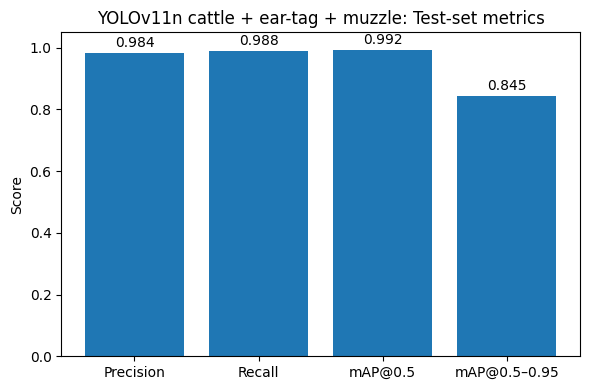

In [ ]:
#@title 10.1.2 Bar chart of test-set evaluation metrics
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
import yaml

# ---- Try to get metrics from metricsA ----
# For recent ultralytics versions:
try:
    # detection metrics object
    box_metrics = metricsA.box
    precision = float(box_metrics.p.mean())      # average precision over classes
    recall    = float(box_metrics.r.mean())      # average recall over classes
    map50     = float(box_metrics.map50)         # mAP@0.5
    map5095   = float(box_metrics.map)           # mAP@0.5:0.95
except AttributeError:
    # Fallback: use results_dict keys
    md = metricsA.results_dict
    precision = float(md.get("metrics/precision(B)", 0.0))
    recall    = float(md.get("metrics/recall(B)", 0.0))
    map50     = float(md.get("metrics/mAP50(B)", 0.0))
    map5095   = float(md.get("metrics/mAP50-95(B)", 0.0))

print(f"Precision:   {precision:.3f}")
print(f"Recall:      {recall:.3f}")
print(f"mAP@0.5:     {map50:.3f}")
print(f"mAP@0.5-0.95:{map5095:.3f}")

# ---- Make bar plot ----
labels = ["Precision", "Recall", "mAP@0.5", "mAP@0.5–0.95"]
values = [precision, recall, map50, map5095]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, values)

# add value labels on top
for b, v in zip(bars, values):
    plt.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.3f}",
             ha='center', va='bottom', fontsize=10)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("YOLOv11n cattle + ear-tag + muzzle: Test-set metrics")
plt.tight_layout()
plt.show()
